# 02 - Crescimento e Receita

Case Olist | Tech Challenge Fase 1

Aluno: Evanio Alves Carvalho

Este notebook responde três perguntas que um investidor faria antes de decidir se coloca dinheiro na Olist:

1. O negócio está crescendo?
2. Se parou de crescer, por quê?
3. Quanto dá para esperar dos próximos meses?

Os dados vêm prontos do notebook `01_limpeza_e_preparacao`. Se ele ainda não foi rodado, este aqui não roda.

## De onde vêm os dados

O tratamento está todo no notebook 01, mas três decisões de lá afetam bastante os números daqui e vale
deixar visível:

- Receita é o preço do produto mais o frete. Não é o que a Olist ganha, é o valor transacionado. Volto
  nisso na conclusão, porque é a maior limitação deste trabalho.
- `payments` e `reviews` foram agregados por pedido antes de serem juntados, senão cada item viraria
  várias linhas e a receita contaria em dobro.
- Nada foi filtrado no 01. O recorte de período e de status é escolha minha e está justificado na
  seção 1 aqui embaixo.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

os.makedirs('output', exist_ok=True)

In [2]:
fato_itens = pd.read_csv('data/processed/fato_itens.csv')
pedidos = pd.read_csv('data/processed/pedidos_tratados.csv')

fato_itens['order_purchase_timestamp'] = pd.to_datetime(fato_itens['order_purchase_timestamp'])

print('itens na base:', len(fato_itens))
print('pedidos na base:', len(pedidos))

itens na base: 112650
pedidos na base: 99441


## 1. O recorte que eu escolhi

Duas decisões, e as duas mudam bastante o resultado final. Preferi mostrar o motivo de cada uma em vez de só
afirmar.

### Qual período analisar

In [3]:
pedidos_por_mes = pedidos['mes'].value_counts().sort_index()
print(pedidos_por_mes)

mes
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Name: count, dtype: int64


As pontas da série são bem diferentes do meio:

- setembro de 2016 tem 4 pedidos
- outubro de 2016 tem 324 pedidos
- novembro de 2016 nem aparece na base
- dezembro de 2016 tem 1 pedido
- setembro e outubro de 2018 somam 20 pedidos

Outubro de 2016 me chamou atenção por não ser tão baixo quanto os outros. Mas 324 pedidos ainda é menos da
metade de janeiro de 2017, que tem 800, e ele vem cercado de meses quase vazios dos dois lados. Parece um
teste da operação, não o começo de um movimento constante.

Para mostrar o tamanho do problema, calculei quanto daria o crescimento dependendo do mês escolhido como
ponto de partida.

In [4]:
receita_mes = fato_itens[~fato_itens['order_status'].isin(['canceled', 'unavailable'])]
receita_mes = receita_mes.groupby('mes')['receita'].sum()

fim = receita_mes['2018-08']

for base in ['2016-09', '2016-10', '2016-12', '2017-01']:
    inicio = receita_mes[base]
    print(base, '- receita: R$', round(inicio, 2),
          '- crescimento até ago/2018:', round((fim / inicio - 1) * 100), '%')

2016-09 - receita: R$ 279.69 - crescimento até ago/2018: 356357 %
2016-10 - receita: R$ 51354.52 - crescimento até ago/2018: 1841 %
2016-12 - receita: R$ 19.62 - crescimento até ago/2018: 5081314 %
2017-01 - receita: R$ 136943.46 - crescimento até ago/2018: 628 %


Os três primeiros números não descrevem o desempenho da empresa, descrevem o fato de que a plataforma
mal tinha começado. E a ausência de novembro de 2016 abre um buraco que impede calcular variação mês a mês.

Escolhi janeiro de 2017 até agosto de 2018, que são o primeiro e o último mês com movimento constante.
Os meses de fora continuam na base e aparecem no gráfico da série completa, para quem quiser conferir.

### Quais status de pedido considerar

In [5]:
janela = pedidos[pedidos['mes'].between('2017-01', '2018-08')]
janela['order_status'].value_counts()

order_status
delivered      96211
shipped         1097
unavailable      602
canceled         580
processing       299
invoiced         296
created            5
approved           2
Name: count, dtype: int64

A maioria é `delivered`, mas tem outros. Fiquei em dúvida se pedido cancelado e indisponível deveria
entrar na receita, então fui ver quantos deles têm produto associado. Essa checagem está no notebook 01 e o
resultado foi:

- `unavailable`: 0% têm produto
- `canceled`: 77,2% têm produto
- `shipped`, `processing`, `invoiced`, `delivered`: 100%

Ou seja, boa parte dessas vendas não se concretizou. Decidi tirar `canceled` e `unavailable` e manter o
resto.

Vale registrar que esse é o ponto onde meu número difere do de quem filtra só por pedido sem item: a
diferença são os pedidos cancelados que têm item, que eu tiro e essa outra abordagem mantém.

In [6]:
dados = fato_itens[
    (fato_itens['mes'].between('2017-01', '2018-08')) &
    (~fato_itens['order_status'].isin(['canceled', 'unavailable']))
].copy()

print('itens que vou analisar:', len(dados))
print('pedidos:', dados['order_id'].nunique())

itens que vou analisar: 111752
pedidos: 97905


## 2. Os números do período

In [7]:
receita_total = dados['receita'].sum()
total_pedidos = dados['order_id'].nunique()

print('Receita total: R$', round(receita_total, 2))
print('  sendo produto: R$', round(dados['price'].sum(), 2))
print('  sendo frete:   R$', round(dados['freight_value'].sum(), 2))
print('Pedidos:', total_pedidos)
print('Clientes:', dados['customer_unique_id'].nunique())

Receita total: R$ 15683706.74
  sendo produto: R$ 13449529.68
  sendo frete:   R$ 2234177.06
Pedidos: 97905
Clientes: 94703


### Quanto vale um pedido

In [8]:
valor_por_pedido = dados.groupby('order_id')['receita'].sum()

media = valor_por_pedido.mean()
mediana = valor_por_pedido.median()
desvio = valor_por_pedido.std()
cv = desvio / media * 100

print('Média: R$', round(media, 2))
print('Mediana: R$', round(mediana, 2))
print('Desvio padrão: R$', round(desvio, 2))
print('Coeficiente de variação:', round(cv), '%')

Média: R$ 160.19
Mediana: R$ 105.28
Desvio padrão: R$ 219.19
Coeficiente de variação: 137 %


A média (R$ 160) ficou bem acima da mediana (R$ 105). Isso é sinal de distribuição assimétrica: a maioria
dos pedidos é mais barata e alguns pedidos caros puxam a média para cima. A mediana representa melhor o pedido
comum, e é ela que eu usaria para dizer quanto vale um pedido da Olist.

O coeficiente de variação deu 137%. Acima de 100% quer dizer que os pedidos são bem diferentes entre si, o que
faz sentido numa loja que vende desde produto barato até móvel caro.

### Sobre os pedidos muito caros

Antes de seguir, quis saber se os valores altos são erro de cadastro ou venda real, porque isso muda se eu
devo tirar ou manter.

In [9]:
q1 = dados['price'].quantile(0.25)
q3 = dados['price'].quantile(0.75)
limite = q3 + 1.5 * (q3 - q1)

outliers = dados[dados['price'] > limite]

print('limite do IQR: R$', round(limite, 2))
print('itens acima:', len(outliers), '(', round(len(outliers) / len(dados) * 100, 1), '%)')
print('preço máximo: R$', dados['price'].max())
print()
print('preços negativos:', (dados['price'] < 0).sum())
print('preços zerados:', (dados['price'] == 0).sum())

limite do IQR: R$

 277.4
itens acima: 8313 ( 7.4 %)
preço máximo: R$ 6735.0

preços negativos: 0
preços zerados: 0


Outlier nem sempre é erro. O valor mais alto é R$ 6.735, que é caro mas possível numa loja que vende
móvel e eletrônico, e não tem preço negativo nem zerado, que seria sinal de cadastro errado.

Decidi manter. Se eu tirasse esses 7,5%, jogaria fora justamente as vendas maiores e a receita ficaria menor
do que é. Para a média não contar a história sozinha, reporto a mediana junto.

## 3. O negócio está crescendo?

In [10]:
por_mes = dados.groupby('mes').agg(
    pedidos=('order_id', 'nunique'),
    receita=('receita', 'sum'),
).reset_index()

por_mes['ticket_medio'] = por_mes['receita'] / por_mes['pedidos']
por_mes

,mes,pedidos,receita,ticket_medio
0,2017-01,787,136943.46,174.006938
1,2017-02,1718,283561.69,165.053370
2,2017-03,2617,425617.96,162.635827
3,2017-04,2377,405848.61,170.739844
4,2017-05,3640,582710.83,160.085393
5,2017-06,3205,499652.24,155.897735
6,2017-07,3946,578753.73,146.668457
7,2017-08,4272,661903.52,154.939963
8,2017-09,4227,717102.72,169.648148
9,2017-10,4547,764756.03,168.189142


In [11]:
primeiro = por_mes['receita'].iloc[0]
ultimo = por_mes['receita'].iloc[-1]

print('receita do primeiro mês: R$', round(primeiro, 2))
print('receita do último mês: R$', round(ultimo, 2))
print('crescimento no período:', round((ultimo / primeiro - 1) * 100), '%')

receita do primeiro mês: R$ 136943.46
receita do último mês: R$ 996973.51
crescimento no período: 628 %


628% parece ótimo. Só que olhando a tabela mês a mês dá para ver que esse crescimento não foi constante,
ele acontece quase todo em 2017. Fui comparar os dois quadrimestres de 2018 para confirmar.

In [12]:
inicio_2018 = por_mes[por_mes['mes'].between('2018-01', '2018-04')]['receita'].mean()
fim_2018 = por_mes[por_mes['mes'].between('2018-05', '2018-08')]['receita'].mean()

print('média mensal de jan a abr de 2018: R$', round(inicio_2018, 2))
print('média mensal de mai a ago de 2018: R$', round(fim_2018, 2))
print('variação:', round((fim_2018 / inicio_2018 - 1) * 100, 1), '%')

média mensal de jan a abr de 2018: R$ 1097578.01
média mensal de mai a ago de 2018: R$ 1050706.36
variação: -4.3 %


Confirmado: a receita para de crescer e até recua um pouco no segundo quadrimestre de 2018. O número de
628% descreve o caminho que a empresa percorreu, não o momento em que ela está.

Para um investidor essa diferença é tudo, porque projetar 628% para frente seria o erro mais caro possível
com esses dados.

### O maior mês foi novembro de 2017, e vale entender por quê

Novembro de 2017 é o maior mês de toda a série, maior até que qualquer mês de 2018. Antes de tratar isso como
um bom sinal, fui abrir o mês por dia.

In [13]:
novembro = dados[dados['mes'] == '2017-11'].copy()
novembro['dia'] = novembro['order_purchase_timestamp'].dt.day

nov_por_dia = novembro.groupby('dia')['order_id'].nunique().reset_index()
nov_por_dia.columns = ['dia', 'pedidos']
nov_por_dia

,dia,pedidos
0,1,109
1,2,119
2,3,138
3,4,111
4,5,140
5,6,186
6,7,157
7,8,173
8,9,186
9,10,163


In [14]:
dia_24 = nov_por_dia[nov_por_dia['dia'] == 24]['pedidos'].values[0]
outros = nov_por_dia[~nov_por_dia['dia'].isin([24, 25, 26, 27])]['pedidos'].mean()

print('pedidos no dia 24:', dia_24)
print('média dos outros dias:', round(outros))
print('o dia 24 teve', round(dia_24 / outros, 1), 'vezes mais pedidos')

pedidos no dia 24: 1166
média dos outros dias: 191
o dia 24 teve 6.1 vezes mais pedidos


O dia 24 de novembro de 2017 foi a Black Friday e sozinho teve 6 vezes mais pedidos que um dia comum.

Isso muda a leitura do gráfico. O maior mês da série não é um novo patamar de vendas, é uma data promocional.
Tanto que dezembro já cai de volta.

## 4. Por que a receita parou de crescer

Essa é a pergunta mais importante do notebook, e não quis deixar só como constatação. Contei quantos
vendedores diferentes e quantos clientes diferentes aparecem em cada mês, para ver qual dos dois lados parou.

In [15]:
por_mes_detalhe = dados.groupby('mes').agg(
    receita=('receita', 'sum'),
    vendedores=('seller_id', 'nunique'),
    clientes=('customer_unique_id', 'nunique'),
).reset_index()

por_mes_detalhe['receita_por_vendedor'] = por_mes_detalhe['receita'] / por_mes_detalhe['vendedores']
por_mes_detalhe[por_mes_detalhe['mes'] >= '2018-01']

,mes,receita,vendedores,clientes,receita_por_vendedor
12,2018-01,1101920.01,968,7088,1138.347118
13,2018-02,979486.16,933,6468,1049.824394
14,2018-03,1152656.99,993,7077,1160.782467
15,2018-04,1156248.89,1116,6863,1036.065314
16,2018-05,1145686.46,1107,6775,1034.947118
17,2018-06,1020381.90,1168,6106,873.614640
18,2018-07,1039783.58,1245,6172,835.167534
19,2018-08,996973.51,1266,6380,787.498823


In [16]:
jan = por_mes_detalhe[por_mes_detalhe['mes'] == '2018-01'].iloc[0]
ago = por_mes_detalhe[por_mes_detalhe['mes'] == '2018-08'].iloc[0]

print('de janeiro a agosto de 2018:')
print('vendedores:', jan['vendedores'], '->', ago['vendedores'],
      '(', round((ago['vendedores'] / jan['vendedores'] - 1) * 100, 1), '%)')
print('clientes:', jan['clientes'], '->', ago['clientes'],
      '(', round((ago['clientes'] / jan['clientes'] - 1) * 100, 1), '%)')
print('receita por vendedor: R$', round(jan['receita_por_vendedor'], 2),
      '-> R$', round(ago['receita_por_vendedor'], 2),
      '(', round((ago['receita_por_vendedor'] / jan['receita_por_vendedor'] - 1) * 100, 1), '%)')

de janeiro a agosto de 2018:
vendedores: 968 -> 1266 ( 30.8 %)
clientes: 7088 -> 6380 ( -10.0 %)
receita por vendedor: R$ 1138.35 -> R$ 787.5 ( -30.8 %)


Achei o que procurava, e não era o que eu esperava.

Vendedor não parou de entrar, foi de 968 para 1.266 ao longo de 2018, um crescimento de 31%. Quem parou foi o
cliente, que caiu de 7.088 para 6.380.

E aí aparece o número que mais me chamou atenção: a receita por vendedor caiu 31% no mesmo período. A Olist
continuou trazendo quem vende, mas não trouxe quem compra junto, então o mesmo bolo passou a ser dividido
entre mais gente.

Isso muda a recomendação inteira. O gargalo não é falta de oferta, é falta de demanda, e recrutar mais
vendedor agora só piora o resultado de quem já está lá.

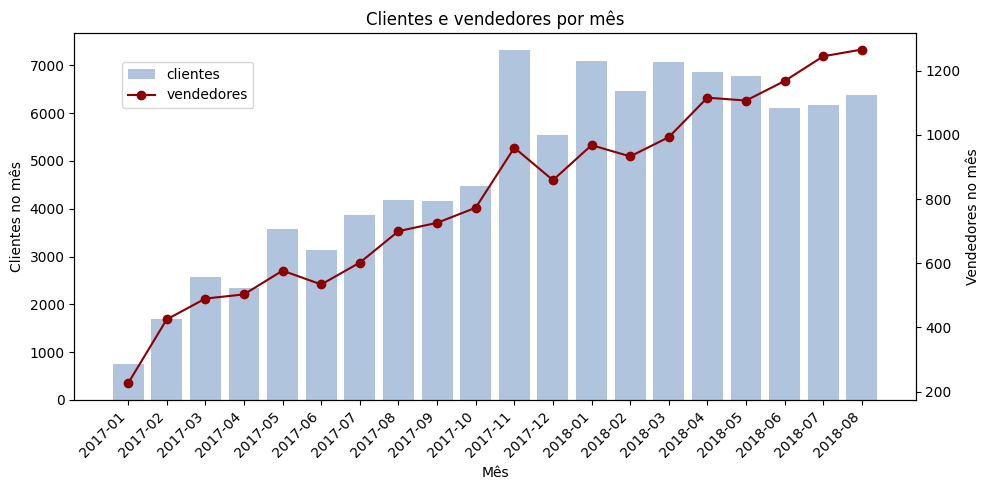

In [17]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(por_mes_detalhe['mes'], por_mes_detalhe['clientes'], color='lightsteelblue', label='clientes')
ax1.set_ylabel('Clientes no mês')
ax1.set_xlabel('Mês')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(por_mes_detalhe['mes'], por_mes_detalhe['vendedores'], color='darkred', marker='o', label='vendedores')
ax2.set_ylabel('Vendedores no mês')

plt.title('Clientes e vendedores por mês')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig('output/chart_09_vendedores_clientes.png', dpi=150)
plt.show()

As duas linhas se separam em 2018: a vermelha, dos vendedores, continua subindo, enquanto as barras de
clientes ficam paradas e depois caem.

## 5. Onde a receita está concentrada

Para avaliar risco, não basta saber quanto entra, importa saber de onde vem. Olhei por categoria, por estado
e por vendedor.

In [18]:
por_categoria = dados.groupby('product_category_name_english')['receita'].sum().reset_index()
por_categoria = por_categoria.sort_values('receita', ascending=False)
por_categoria.to_csv('output/kpi_receita_categoria.csv', index=False)

top5_cat = por_categoria.head(5)['receita'].sum() / receita_total * 100
print('total de categorias:', len(por_categoria))
print('as 5 maiores somam:', round(top5_cat, 1), '% da receita')
por_categoria.head(10)

total de categorias: 72
as 5 maiores somam: 39.3 % da receita


,product_category_name_english,receita
43,health_beauty,1432213.38
71,watches_gifts,1294824.43
7,bed_bath_table,1239779.55
65,sports_leisure,1144753.87
15,computers_accessories,1049201.49
39,furniture_decor,892437.53
49,housewares,770492.60
20,cool_stuff,702849.36
5,auto,676854.18
42,garden_tools,578060.01


In [19]:
por_estado = dados.groupby('customer_state').agg(
    receita=('receita', 'sum'),
    pedidos=('order_id', 'nunique'),
).reset_index().sort_values('receita', ascending=False)
por_estado.to_csv('output/kpi_receita_estado.csv', index=False)

sp = por_estado.iloc[0]['receita'] / receita_total * 100
top5_uf = por_estado.head(5)['receita'].sum() / receita_total * 100

print('total de estados:', len(por_estado))
print('São Paulo sozinho:', round(sp, 1), '%')
print('os 5 maiores:', round(top5_uf, 1), '%')
print('os outros', len(por_estado) - 5, 'estados:', round(100 - top5_uf, 1), '%')
por_estado.head(10)

total de estados: 27
São Paulo sozinho: 37.4 %
os 5 maiores: 73.1 %
os outros 22 estados: 26.9 %


,customer_state,receita,pedidos
25,SP,5863232.66,41021
18,RJ,2105549.64,12654
10,MG,1837646.07,11457
22,RS,873634.76,5395
17,PR,791701.89,4962
4,BA,605913.32,3340
23,SC,605522.98,3590
6,DF,350127.10,2114
8,GO,339389.70,1990
7,ES,322013.89,2014


In [20]:
por_vendedor = dados.groupby(['seller_id', 'seller_state'])['receita'].sum().reset_index()
por_vendedor = por_vendedor.sort_values('receita', ascending=False)
por_vendedor.to_csv('output/kpi_top_sellers.csv', index=False)

top10_vend = por_vendedor.head(10)['receita'].sum() / receita_total * 100
print('vendedores no período:', len(por_vendedor))
print('os 10 maiores somam:', round(top10_vend, 1), '% da receita')

vendedores no período: 3029
os 10 maiores somam: 12.9 % da receita


Os três olhares dão respostas diferentes, e é isso que interessa.

Por categoria está tranquilo: são 72 categorias e as 5 maiores fazem 39%. Por vendedor também: são 3.029 e os
10 maiores fazem só 13%, então a empresa não depende de poucos fornecedores.

Por estado a história muda. São Paulo sozinho é 37% e os cinco maiores chegam a 73%, sobrando 27% para os
outros 22 estados.

O risco do negócio é geográfico, e é justamente isso que investigo no notebook 03.

## 6. Gráficos

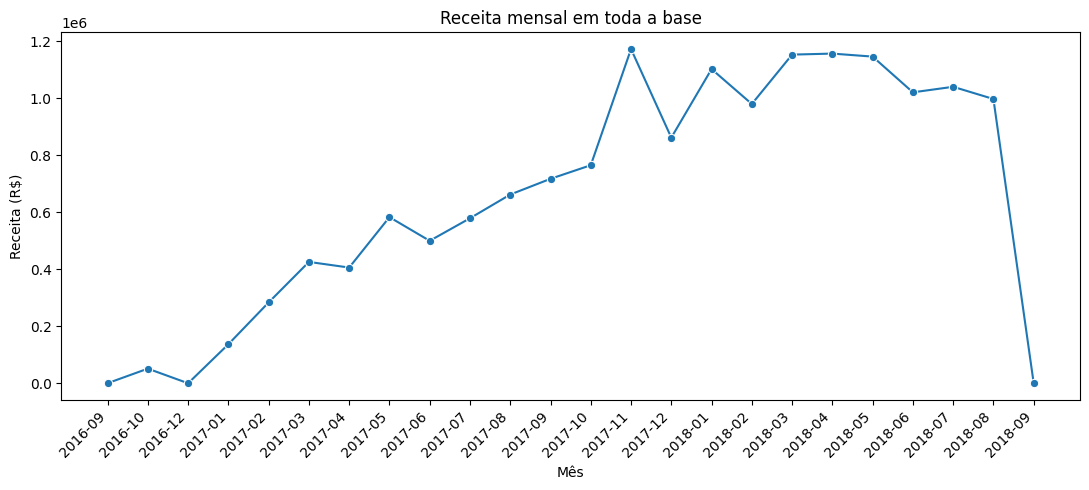

In [21]:
todos_meses = fato_itens[~fato_itens['order_status'].isin(['canceled', 'unavailable'])]
todos_meses = todos_meses.groupby('mes')['receita'].sum().reset_index()
todos_meses.to_csv('output/kpi_serie_completa.csv', index=False)

plt.figure(figsize=(11, 5))
sns.lineplot(data=todos_meses, x='mes', y='receita', marker='o')
plt.title('Receita mensal em toda a base')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/chart_00_serie_completa.png', dpi=150)
plt.show()

Aqui fica visível: 2016 e o finalzinho de 2018 quase encostados no zero. Por isso ficaram de fora.

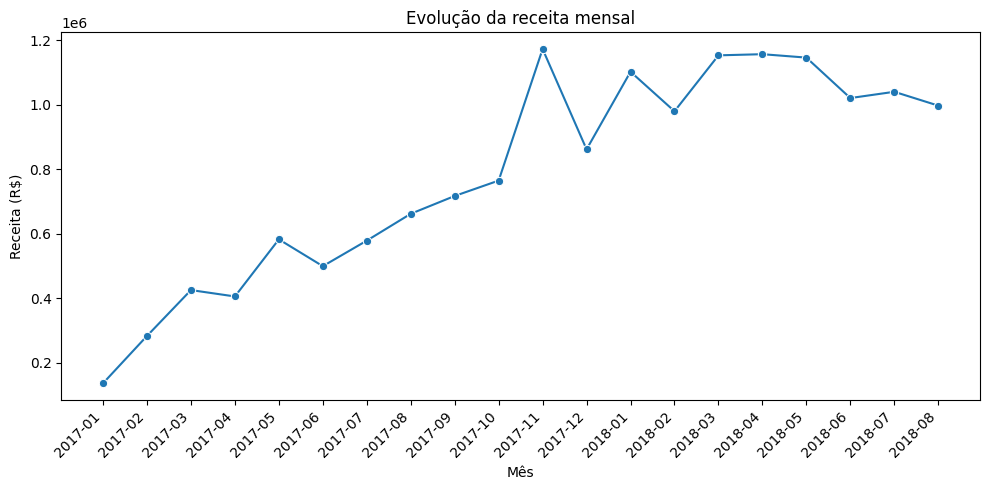

In [22]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=por_mes, x='mes', y='receita', marker='o')
plt.title('Evolução da receita mensal')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/chart_01_evolucao_mensal.png', dpi=150)
plt.show()

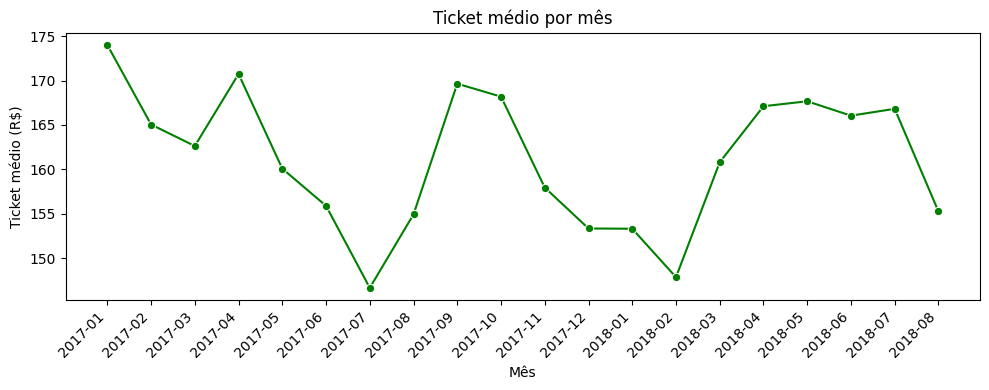

In [23]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=por_mes, x='mes', y='ticket_medio', marker='o', color='green')
plt.title('Ticket médio por mês')
plt.xlabel('Mês')
plt.ylabel('Ticket médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/chart_02_ticket_medio.png', dpi=150)
plt.show()

O ticket médio quase não se mexe no período todo. Junto com o crescimento de pedidos, isso mostra que a
receita cresceu por vender mais, não por vender mais caro.

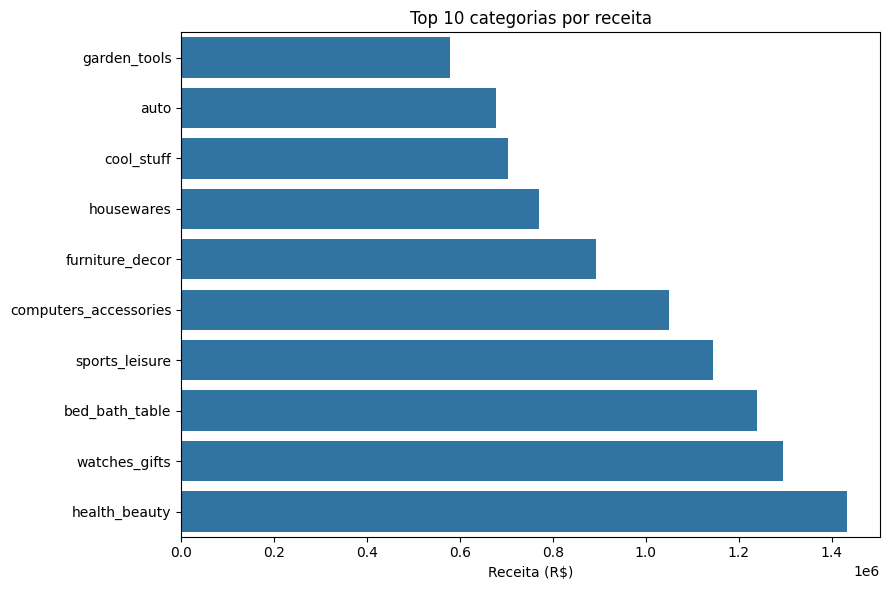

In [24]:
top10_cat = por_categoria.head(10).sort_values('receita')

plt.figure(figsize=(9, 6))
sns.barplot(data=top10_cat, x='receita', y='product_category_name_english')
plt.title('Top 10 categorias por receita')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/chart_03_top_categorias.png', dpi=150)
plt.show()

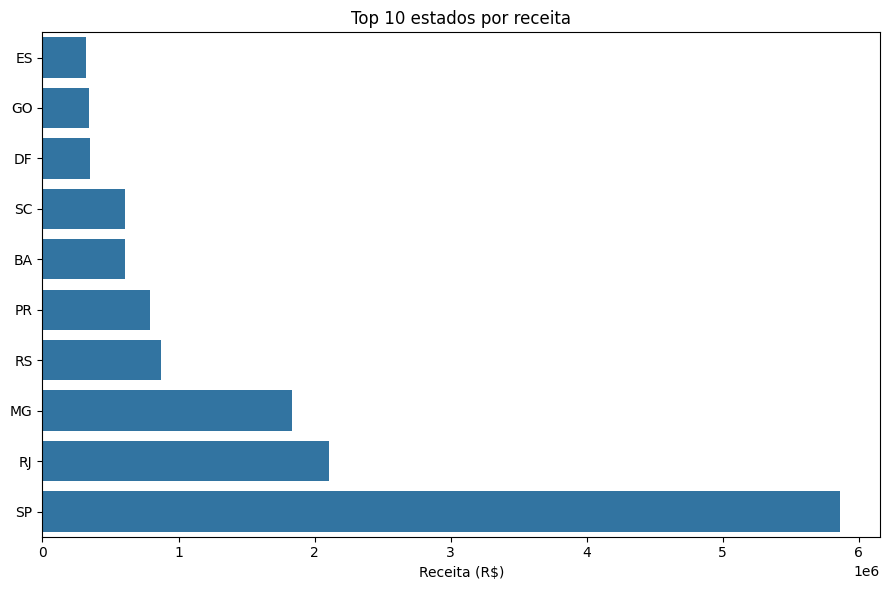

In [25]:
top10_uf = por_estado.head(10).sort_values('receita')

plt.figure(figsize=(9, 6))
sns.barplot(data=top10_uf, x='receita', y='customer_state')
plt.title('Top 10 estados por receita')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/chart_04_top_estados.png', dpi=150)
plt.show()

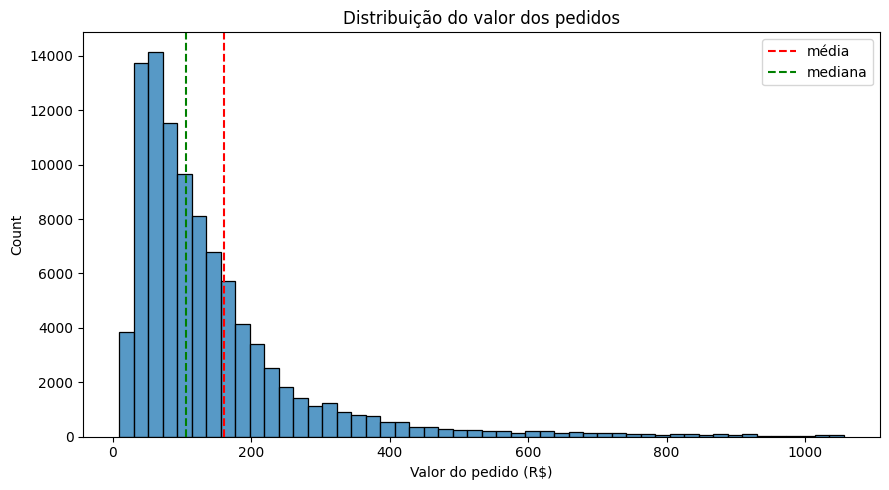

In [26]:
corte = valor_por_pedido.quantile(0.99)

plt.figure(figsize=(9, 5))
sns.histplot(valor_por_pedido[valor_por_pedido <= corte], bins=50)
plt.axvline(media, color='red', linestyle='--', label='média')
plt.axvline(mediana, color='green', linestyle='--', label='mediana')
plt.title('Distribuição do valor dos pedidos')
plt.xlabel('Valor do pedido (R$)')
plt.legend()
plt.tight_layout()
plt.savefig('output/chart_05_distribuicao_ticket.png', dpi=150)
plt.show()

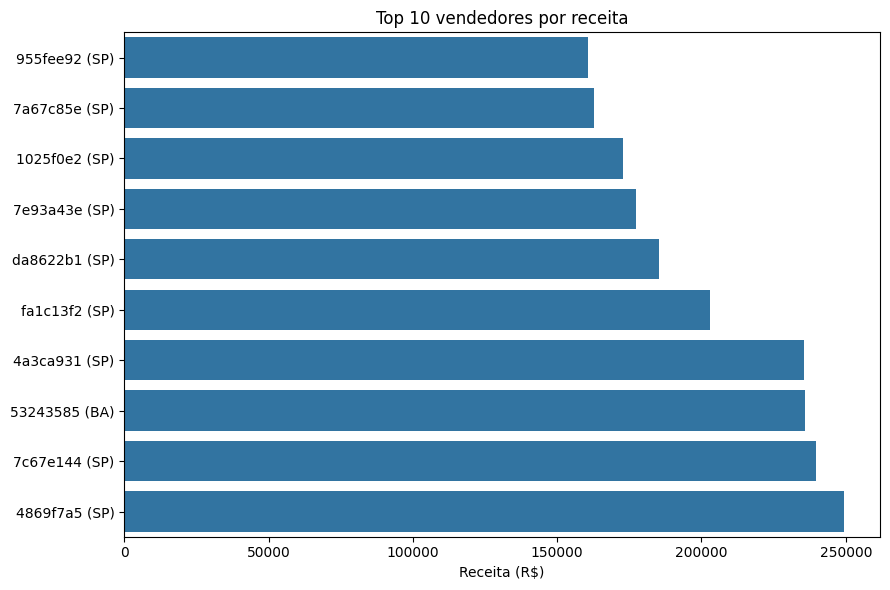

In [27]:
top10_vend = por_vendedor.head(10).sort_values('receita').copy()
top10_vend['vendedor'] = top10_vend['seller_id'].str[:8] + ' (' + top10_vend['seller_state'] + ')'

plt.figure(figsize=(9, 6))
sns.barplot(data=top10_vend, x='receita', y='vendedor')
plt.title('Top 10 vendedores por receita')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/chart_06_top_sellers.png', dpi=150)
plt.show()

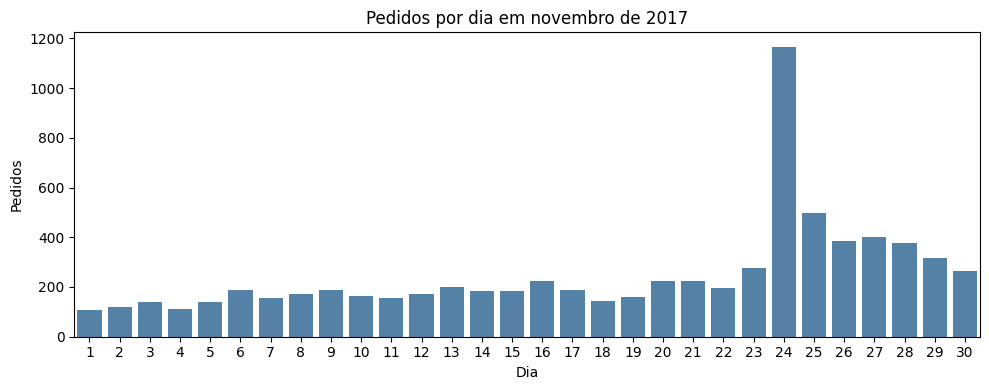

In [28]:
plt.figure(figsize=(10, 4))
sns.barplot(data=nov_por_dia, x='dia', y='pedidos', color='steelblue')
plt.title('Pedidos por dia em novembro de 2017')
plt.xlabel('Dia')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('output/chart_07_black_friday.png', dpi=150)
plt.show()

A barra bem alta é o dia 24, a Black Friday.

## 7. Quanto esperar dos próximos meses

O desafio pede uma previsão quando for possível. Como a receita está estável, usei a média dos últimos meses
para estimar os próximos. É uma conta simples, mas serve para dar ordem de grandeza.

In [29]:
ultimos_3 = por_mes.tail(3)
print(ultimos_3[['mes', 'receita']])
print()

media_recente = ultimos_3['receita'].mean()
print('média dos últimos 3 meses: R$', round(media_recente, 2))
print('projeção para o trimestre seguinte: R$', round(media_recente * 3, 2))

        mes     receita
17  2018-06  1020381.90
18  2018-07  1039783.58
19  2018-08   996973.51

média dos últimos 3 meses: R$ 1019046.33
projeção para o trimestre seguinte: R$ 3057138.99


In [30]:
trimestre_2017 = por_mes[por_mes['mes'].between('2017-09', '2017-11')]['receita'].sum()

print('set a nov de 2017 (real): R$', round(trimestre_2017, 2))
print('set a nov de 2018 (projetado): R$', round(media_recente * 3, 2))
print('diferença:', round((media_recente * 3 / trimestre_2017 - 1) * 100, 1), '%')

set a nov de 2017 (real): R$ 2654050.43
set a nov de 2018 (projetado): R$ 3057138.99
diferença: 15.2 %


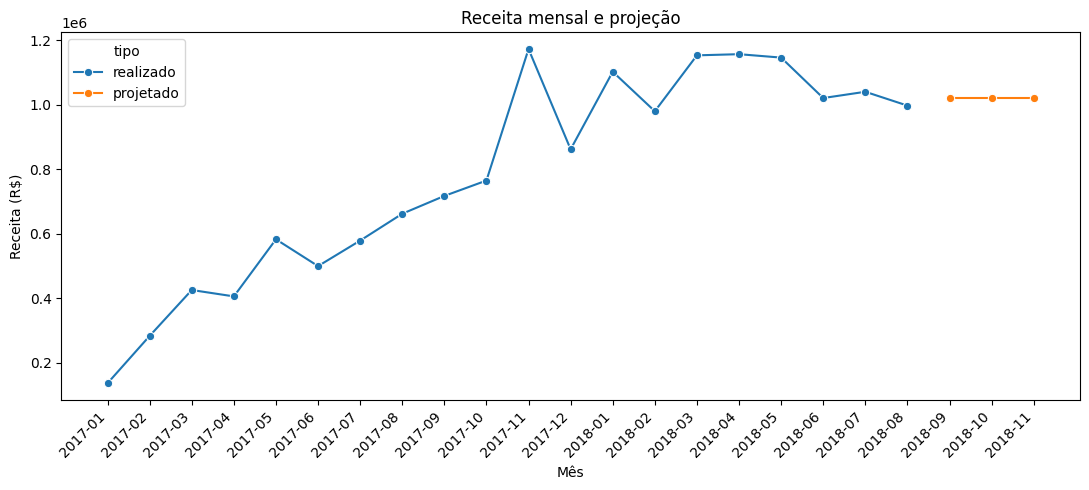

In [31]:
previsao = pd.DataFrame({
    'mes': ['2018-09', '2018-10', '2018-11'],
    'receita': [media_recente] * 3,
})
previsao.to_csv('output/kpi_previsao.csv', index=False)

grafico = pd.concat([
    por_mes[['mes', 'receita']].assign(tipo='realizado'),
    previsao.assign(tipo='projetado'),
])

plt.figure(figsize=(11, 5))
sns.lineplot(data=grafico, x='mes', y='receita', hue='tipo', marker='o')
plt.title('Receita mensal e projeção')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/chart_08_previsao.png', dpi=150)
plt.show()

O resultado é uma receita em torno de R$ 1 milhão por mês, mais ou menos R$ 3 milhões no trimestre.

Mas o número em si é o menos importante aqui. O que interessa é que, com os dados que existem, a melhor
estimativa possível para os próximos meses é repetir os últimos três. A projeção não aponta subida nem queda,
aponta mais do mesmo, e isso é a confirmação em número do platô que apareceu no gráfico.

Duas ressalvas que mudam como ler esse número:

- O método só vale porque a receita está estável. Se ela ainda estivesse subindo forte, tirar média daria
  errado e eu teria que usar outra coisa.
- Novembro tem Black Friday, e a média não captura data promocional. Como a Black Friday sozinha multiplicou
  por 6 os pedidos de um dia, novembro provavelmente ficaria acima dessa linha.

Como a base termina em agosto de 2018, não tem como conferir se a projeção acertou. Por isso ela serve como
referência de ordem de grandeza, e não como meta.

In [32]:
por_mes.to_csv('output/kpi_evolucao_mensal.csv', index=False)
nov_por_dia.to_csv('output/kpi_novembro_diario.csv', index=False)
por_mes_detalhe.to_csv('output/kpi_vendedores_clientes.csv', index=False)
print('indicadores salvos')

indicadores salvos


## 8. O que eu concluo

A Olist faturou R$ 15,68 milhões entre janeiro de 2017 e agosto de 2018, em 97.905 pedidos, e o crescimento do
primeiro para o último mês foi de cerca de 628%. Esse número impressiona, mas sozinho ele engana: ele descreve
2017, não 2018. A receita sobe forte no primeiro ano e depois estaciona, e a projeção reforça isso, porque a
melhor estimativa para os meses seguintes é repetir os últimos.

O motivo do platô eu consegui rastrear. Ao longo de 2018 os vendedores aumentaram 31% e mesmo assim a receita
não subiu. Os clientes é que caíram 10%, e a receita por vendedor encolheu 31%. A plataforma continuou
atraindo quem vende sem atrair quem compra na mesma velocidade, então o limite está do lado da demanda.

O crescimento também veio de vender mais, não de vender mais caro. O valor do pedido praticamente não mudou,
com média de R$ 160 e mediana de R$ 105.

Sobre concentração, depende de onde se olha. Por categoria e por vendedor a receita está bem espalhada. Por
estado não: São Paulo sozinho é 37% e os cinco maiores chegam a 73%. Esse é o risco mais concreto que
encontrei, e é o que o notebook 03 investiga.

Preciso deixar clara uma limitação. O que eu chamo de receita aqui é o valor transacionado, produto mais
frete. Essa base não diz quanto a Olist fica de comissão, então não dá para calcular lucro nem margem, e
nenhuma conclusão minha fala sobre rentabilidade.

A pergunta que fica para o notebook 03: por que a receita está tão presa a São Paulo, e o que impede os
outros 22 estados de comprarem mais?